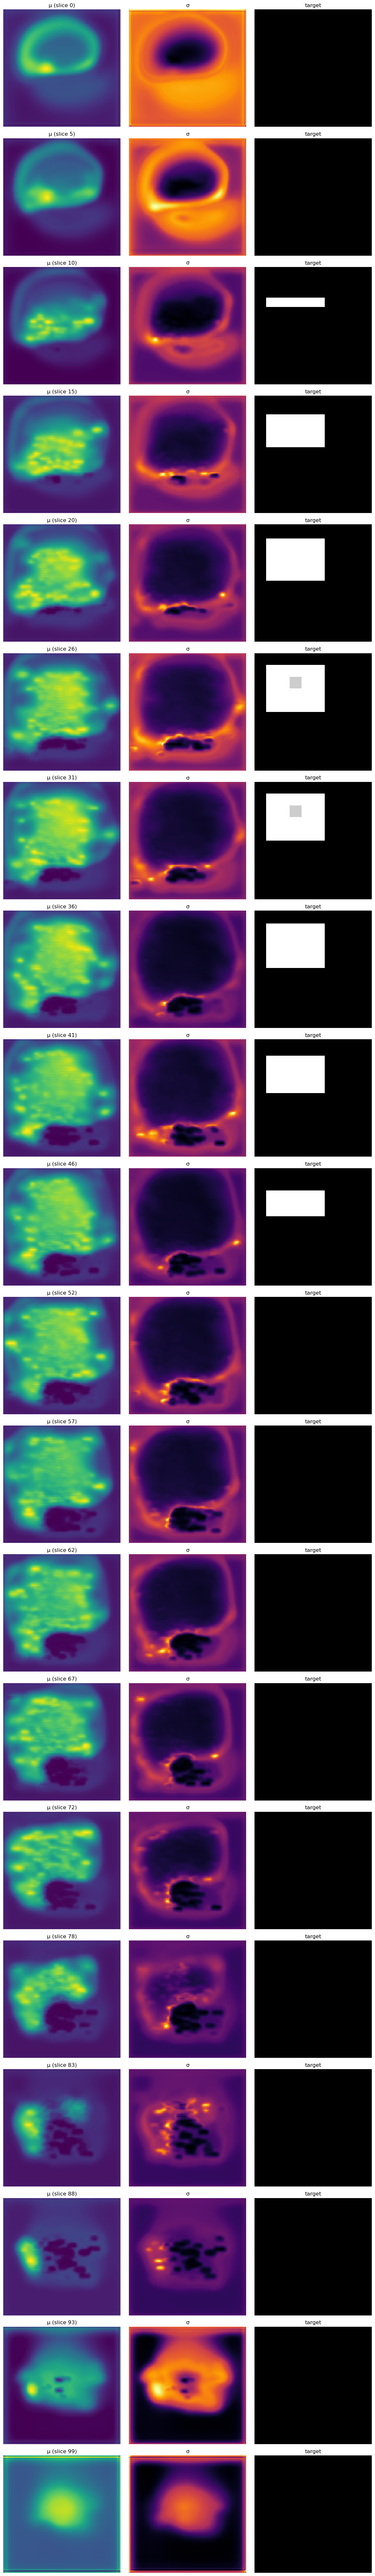

/scratch/zdaher/64556004/ipykernel_20315/1617500124.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  history = torch.load("unet_outputs_prob/loss_history.pt")


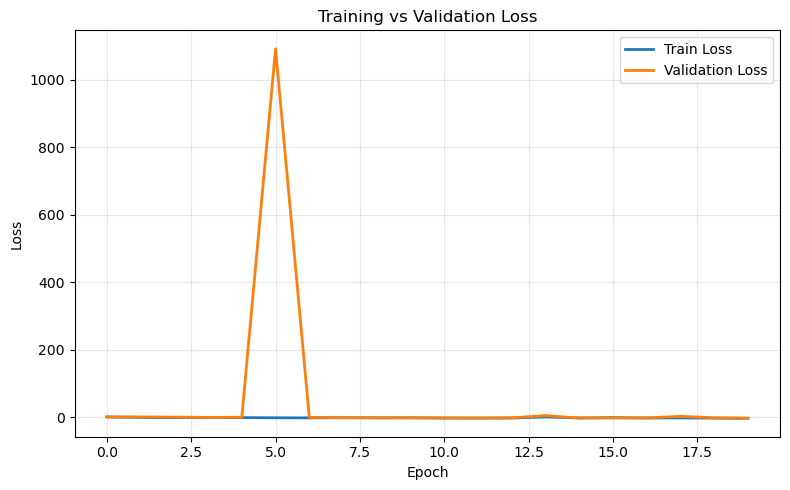

In [5]:
import torch
import matplotlib.pyplot as plt

history = torch.load("unet_outputs_prob/loss_history.pt")

train_losses = history["train_losses"]
val_losses   = history["val_losses"]

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## I. POCA class

#### This class performs the PoCA reconstruction from a given csv file containing the hit information from the detector.
#### It is implicitly used by `precompute_poca.py`, which processes all the csv files in a given directory to pre-compute the PoCA-level information which is needed for training an nn model.
#### The user can, however, instantiate the POCA class with a specific csv file to do the reconstruction and visualize PoCA density projections. The POCA object can also be used as a diagnostic to visualize the voxelized input channels to the nn model.

In [1]:
from src.poca_reconstruction import POCA

#### Create an instance of the POCA class with the path to a specific csv file of hit information. The user has to define the VOI xyz limits, in mm, which must be compatible with the ground truth for training.

In [2]:
poca = POCA(
    "/home/ucl/cp3/zdaher/simulation-cultural-heritage/muography-geant4/outputs/boneInConcrete/processed_root/scene_trial_0_processed.csv",
    xyz_min = (-600, -600, -2700),
    xyz_max = (600, 600, -1300),
    )

The `plot_poca_projections` method is used to plot projections of the PoCA density cloud.

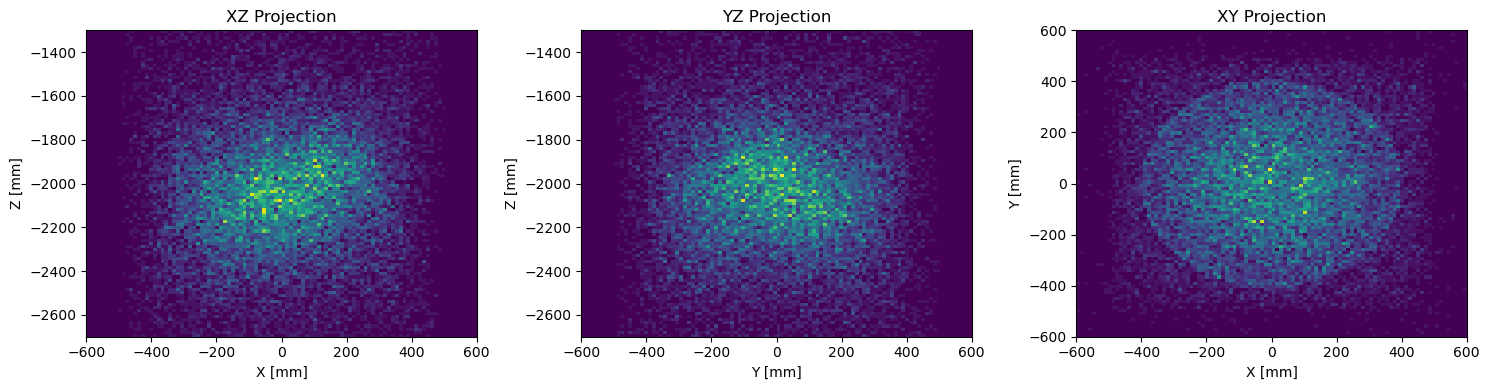

In [3]:
poca.plot_poca_projections(poca.poca, bins = 100)

The precomputed PoCA grids are obtained by executing `utils/precompute_poca.py`, in order to allow for faster training.  
The `MuonDataset` class is used for loading the training/validation/test datasets by iterating over the saved PoCA files. Below is an example usage of this dataset class.

## II. MuonDataset class

In [4]:
from src.data import MuonDataset

#### Define the path to saved PoCA files, and to to the corresponding ground truth maps.

In [5]:
poca_dir = '/home/ucl/cp3/zdaher/simulation-cultural-heritage/muography-geant4/outputs/boneInConcrete/poca_voxels/' 
target_dir = '/home/ucl/cp3/zdaher/simulation-cultural-heritage/muography-geant4/outputs/boneInConcrete/density_maps/'

In [6]:
dataset = MuonDataset(
    poca_dir=poca_dir,
    target_dir=target_dir,
    normalize_stats=None
)

print(f"Dataset size: {len(dataset)} samples") # number of samples found
print(f"Grid size D: {dataset.D}")
print(f"VOI min: {dataset.voi_min}, VOI max: {dataset.voi_max}")

Dataset size: 100 samples
Grid size D: 100
VOI min: [ -600.  -600. -2700.], VOI max: [  600.   600. -1300.]


#### Let's have a look at a sample

In [7]:
x, tgt, mask, name = dataset[0]

print("Input shape:", x.shape)          # (3, D, D, D)
print("Target shape:", tgt.shape)       # (1, D, D, D)
print("Mask shape:", mask.shape)        # (1, D, D, D)
print("Name:", name)

Input shape: (3, 100, 100, 100)
Target shape: (1, 100, 100, 100)
Mask shape: (1, 100, 100, 100)
Name: scene_trial_0


#### The first dimension of the input shape is the number of input channels to our nn.

### Visualizing a slice

#### Below is an example plot of XY slices (at mid-z) of the three channel grids.


/scratch/zdaher/64556004/ipykernel_152116/922428641.py:7: RuntimeWarning: divide by zero encountered in log
  plt.subplot(131); plt.title("S slice"); plt.imshow(np.log(x[0,:, :, i])); plt.colorbar();


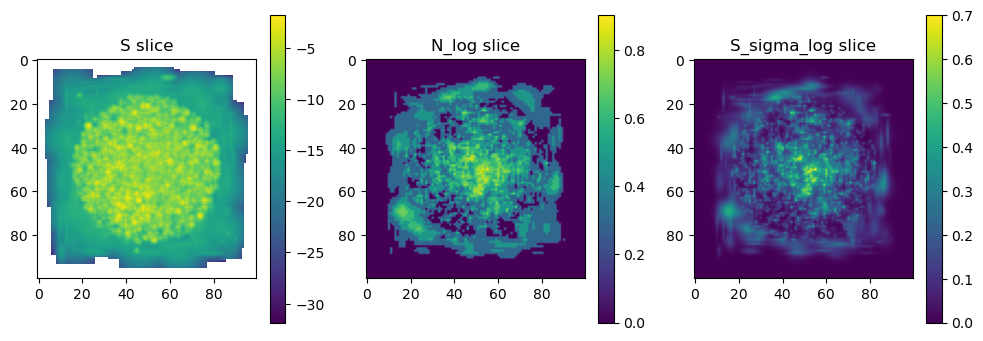

In [8]:
i = dataset.D // 2

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))
plt.subplot(131); plt.title("S slice"); plt.imshow(np.log(x[0,:, :, i])); plt.colorbar();
plt.subplot(132); plt.title("N_log slice"); plt.imshow(x[1,:, :, i]); plt.colorbar()
plt.subplot(133); plt.title("S_sigma_log slice"); plt.imshow(x[2,:, :, i]); plt.colorbar()
plt.show()


### Using DataLoader
#### An instance of a DataLoader class is used during training to load batches of these datasets.

In [9]:
import torch
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4, # set to 0 if error appears
    pin_memory=True
)

for x, tgt, mask, names in loader:
    print("Batch X:", x.shape)     # (B, 3, D, D, D)
    print("Batch tgt:", tgt.shape) # (B, 1, D, D, D)
    print("Batch mask:", mask.shape)  # (B, 1, D, D, D)
    break


Batch X: torch.Size([4, 3, 100, 100, 100])
Batch tgt: torch.Size([4, 1, 100, 100, 100])
Batch mask: torch.Size([4, 1, 100, 100, 100])


#### Notice how DataLoader automatically converts the arrays to torch tensors.
#### Also note that first dimension of these loaded tensors is the batch size, i.e. number of samples loaded at a time.

## ProbUNet3D model

#### We now create an object model to train as an example.

In [10]:
from src.model import ProbUNet3D

model = ProbUNet3D(
    in_channels=3,  # S,N, S_sigma
    out_channels=2,  # mean mu, std log(sigma)
    base_features=16,
    depth=4
).cuda()

#### A single prediction of the model on an iteration of the DataLoader

In [11]:
x, tgt, mask, name = next(iter(loader))

x = x.cuda()
tgt = tgt.cuda()
mask = mask.cuda()

pred = model(x)

print("pred shape:", pred.shape)  # (B, 2, D, D, D)
mu = pred[:,0:1]
log_sigma = pred[:,1:2]

print("mu range:", mu.min().item(), mu.max().item())
print("log_sigma range:", log_sigma.min().item(), log_sigma.max().item())


pred shape: torch.Size([4, 2, 100, 100, 100])
mu range: -3.3474225997924805 2.1449098587036133
log_sigma range: -1.736335039138794 2.79062819480896


#### Below is an example training loop for a few epochs

In [42]:
import torch
from torch.utils.data import DataLoader

from src.data import MuonDataset
from src.model import ProbUNet3D, nll_loss_masked

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_path = "/home/ucl/cp3/zdaher/MuProbNet/dataset_boneInConcrete/"

train_dataset = MuonDataset(
    poca_dir   = f"{data_path}/train/poca_voxels",
    target_dir = f"{data_path}/train/density_maps",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4, # set to 0 if issues occur
    pin_memory=False,
)

# Model + Optimizer
model = ProbUNet3D(
    in_channels=3,
    out_channels=2,
    base_features=16,
    depth=4
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# example of a few training epochs

n_epochs = 2

for epoch in range(1, n_epochs + 1):

    model.train()
    total_loss = 0
    n_batches = 0

    print(f"\nEpoch {epoch}/{n_epochs}")

    for batch_idx, (x, tgt, mask, name) in enumerate(train_loader):
        
        x    = x.to(device)
        tgt  = tgt.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = nll_loss_masked(pred, tgt, mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

        if batch_idx % 5 == 0:
            print(f"  batch {batch_idx:3d} | loss={loss.item():.4f}")

    print(f"Epoch {epoch} avg loss = {total_loss / n_batches:.4f}")


Device: cuda

Epoch 1/2
  batch   0 | loss=1.5663
  batch   5 | loss=0.7311
  batch  10 | loss=0.6153
  batch  15 | loss=0.5371
  batch  20 | loss=0.4839
  batch  25 | loss=0.4216
  batch  30 | loss=0.3442
  batch  35 | loss=0.3003
  batch  40 | loss=0.2254
  batch  45 | loss=0.1788
  batch  50 | loss=0.1275
  batch  55 | loss=0.0874
  batch  60 | loss=0.0276
  batch  65 | loss=-0.0230
  batch  70 | loss=-0.0933
  batch  75 | loss=-0.1583
Epoch 1 avg loss = 0.2859

Epoch 2/2
  batch   0 | loss=-0.1947
  batch   5 | loss=-0.2690
  batch  10 | loss=-0.3348
  batch  15 | loss=-0.3951
  batch  20 | loss=-0.5154
  batch  25 | loss=-0.5952
  batch  30 | loss=-0.6586
  batch  35 | loss=-0.7726
  batch  40 | loss=-0.8427
  batch  45 | loss=-0.9147
  batch  50 | loss=-0.9908
  batch  55 | loss=-1.1156
  batch  60 | loss=-1.1869
  batch  65 | loss=-1.2660
  batch  70 | loss=-1.3905
  batch  75 | loss=-1.4824
Epoch 2 avg loss = -0.8284


#### While it is possible to train the model in a jupyter notebook, we will train with running a script (`train/train.py`) in terminal mode for the sake of speed. 

#### Inspecting the prediction of the last update step

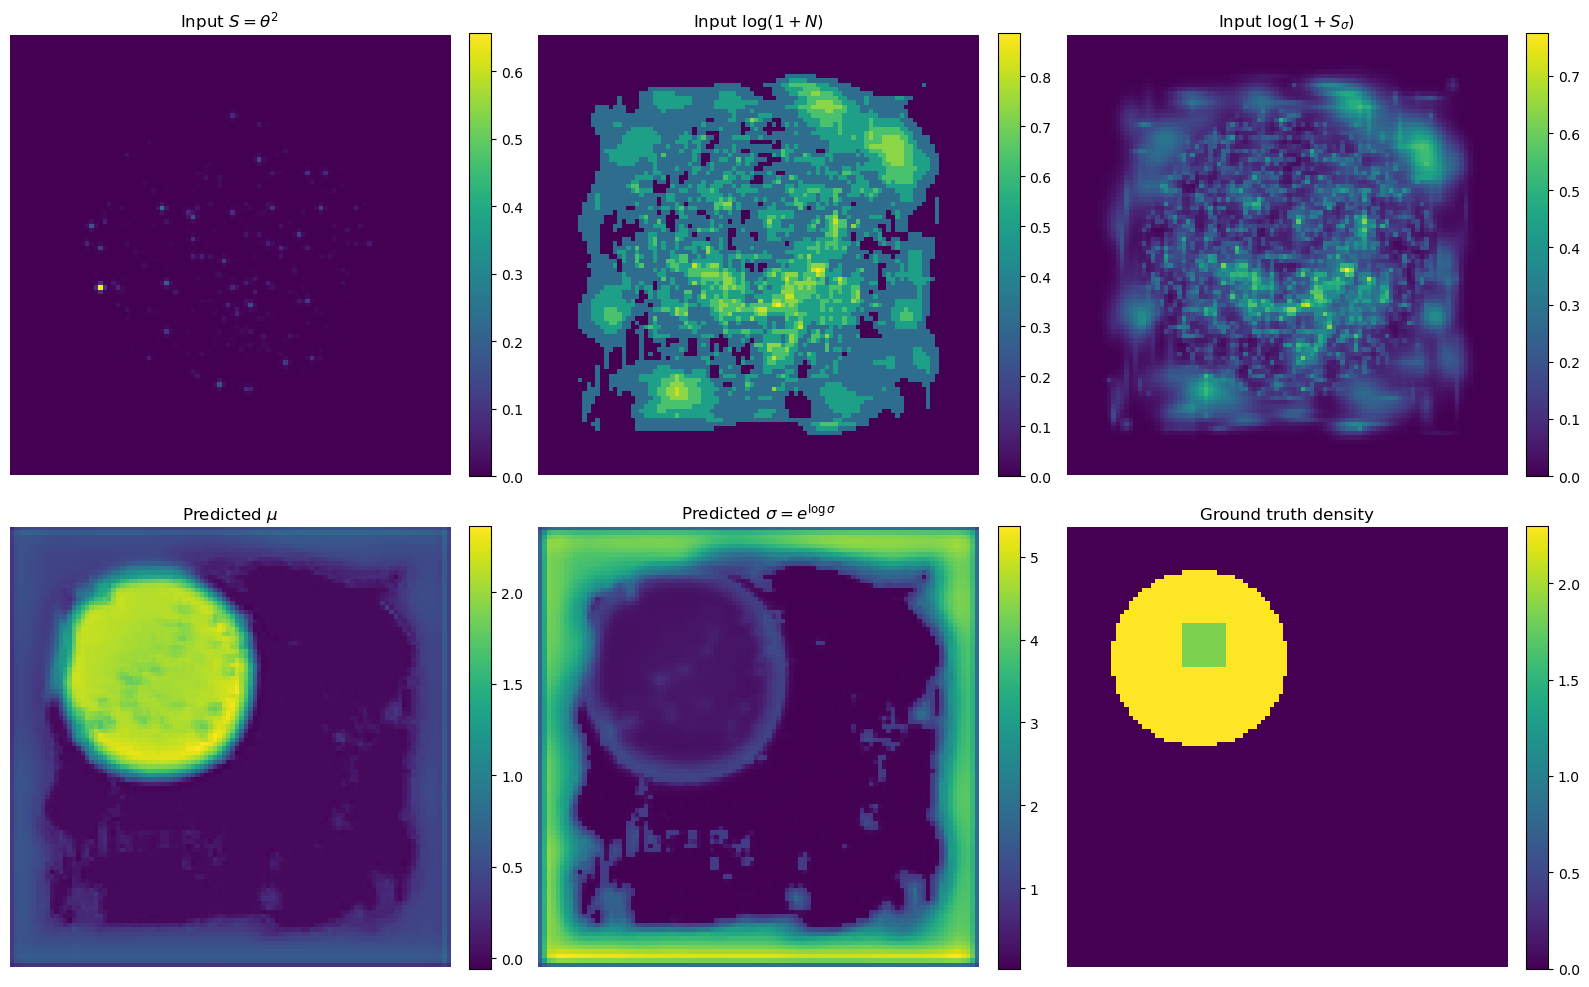

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ----------------------------------------
# Extract fields from last forward step
# ----------------------------------------
S           = x[0,0].detach().cpu().numpy()
N_log       = x[0,1].detach().cpu().numpy()
S_sigma_log = x[0,2].detach().cpu().numpy()

gt          = tgt[0,0].detach().cpu().numpy()

mu          = pred[0,0].detach().cpu().numpy()
sigma       = torch.exp(pred[0,1]).detach().cpu().numpy()

mask_np     = mask[0,0].detach().cpu().numpy()

# Mid-slice
D = mu.shape[0]
z = 40

# ----------------------------------------
# Plot
# ----------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

def show(ax, data, title):
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Inputs
show(axs[0,0], S[:, : ,z], r"Input $S = \theta^2$")
show(axs[0,1], N_log[:, : ,z], r"Input $\log(1+N)$")
show(axs[0,2], S_sigma_log[:, : ,z], r"Input $\log(1+S_\sigma)$")

# Outputs
show(axs[1,0], mu[:, : ,z], r"Predicted $\mu$")
show(axs[1,1], sigma[:, : ,z], r"Predicted $\sigma = e^{\log \sigma}$")

# Ground truth
show(axs[1,2], gt[:, : ,z], "Ground truth density")

plt.tight_layout()
plt.show()



#### For proper training, a common practice is to split the dataset into separate training/validation/testing datasets in 80/10/10 fractions. The model is validated against the validation dataset during training but without updating model parameters to detect any overfitting. The testing dataset is evaluated after training in evaluation mode (model.eval()).

#### The script `train/split_dataset.py` splits our full dataset and stores the different datasets in separate folders.

#### Below, we show an example of loading a pre-trained model, whose final state is saved in `train/train_outputs`. The model was trained on a split dataset found in `train/datasets_boneInConcrete`.

#### The loaded model will be evaluated with a test dataset `train/datasets_boneInConcrete/test/`

In [53]:
from src.model import ProbUNet3D  # adjust path if needed

ckpt_path = "/home/ucl/cp3/zdaher/MST_NN/train/train_outputs/best_model.pt"
ckpt = torch.load(ckpt_path, map_location=device)

model = ProbUNet3D(in_channels=3, out_channels=2, base_features=16).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded model from:", ckpt_path)

Loaded model from: /home/ucl/cp3/zdaher/MST_NN/train/train_outputs/best_model.pt


/scratch/zdaher/64556004/ipykernel_152116/3957025409.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [54]:
from src.data import MuonDataset
poca_dir   = "/home/ucl/cp3/zdaher/MST_NN/train/datasets_boneInConcrete/test/poca_voxels"
target_dir = "/home/ucl/cp3/zdaher/MST_NN/train/datasets_boneInConcrete/test/density_maps"

val_ds = MuonDataset(poca_dir, target_dir)
val_dl = DataLoader(val_ds, batch_size=2, num_workers=0)

In [55]:
x, y, mask, name = next(iter(val_dl))
x = x.to(device)
y = y.to(device)
mask = mask.to(device)

with torch.no_grad():
    pred = model(x)

mu = pred[:, 0]
sigma = torch.exp(pred[:, 1])

print("Shapes:")
print("mu:", mu.shape)
print("sigma:", sigma.shape)
print("target:", y.shape)

Shapes:
mu: torch.Size([2, 100, 100, 100])
sigma: torch.Size([2, 100, 100, 100])
target: torch.Size([2, 1, 100, 100, 100])


In [56]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_slices(mu, sigma, target, batch_idx=0, axis="z", n_slices=4):
    """
    mu, sigma, target: tensors of shape [B, D, D, D]
    batch_idx: which element in the batch to visualize
    axis: "x", "y", or "z"
    n_slices: number of slices to show
    """

    # --- select sample ---
    mu_b     = mu[batch_idx].detach().cpu().squeeze(0)
    sigma_b  = sigma[batch_idx].detach().cpu().squeeze(0)
    target_b = target[batch_idx].detach().cpu().squeeze(0)

    if mu_b.ndim != 3:
        raise ValueError(f"Expected (D,D,D), got {mu_b.shape}")

    D = mu_b.shape[0]

    # --- choose slice indices ---
    idxs = np.linspace(0, D-1, n_slices).astype(int)

    # --- prepare figure ---
    fig, axs = plt.subplots(n_slices, 3, figsize=(12, 4*n_slices))

    for row, idx in enumerate(idxs):

        if axis == "z":
            s_mu     = mu_b[:, :, idx]
            s_sigma  = sigma_b[:, :, idx]
            s_target = target_b[:, :, idx]
        elif axis == "y":
            s_mu     = mu_b[:, idx, :]
            s_sigma  = sigma_b[:, idx, :]
            s_target = target_b[:, idx, :]
        elif axis == "x":
            s_mu     = mu_b[idx, :, :]
            s_sigma  = sigma_b[idx, :, :]
            s_target = target_b[idx, :, :]
        else:
            raise ValueError("axis must be x, y, or z")

        axs[row, 0].imshow(s_mu.numpy(), cmap="viridis")
        axs[row, 0].set_title(f"μ (slice {idx})")

        axs[row, 1].imshow(s_sigma.numpy(), cmap="inferno")
        axs[row, 1].set_title("σ")

        axs[row, 2].imshow(s_target.numpy(), cmap="gray")
        axs[row, 2].set_title("target")

        for col in range(3):
            axs[row, col].axis("off")

    plt.tight_layout()
    plt.show()



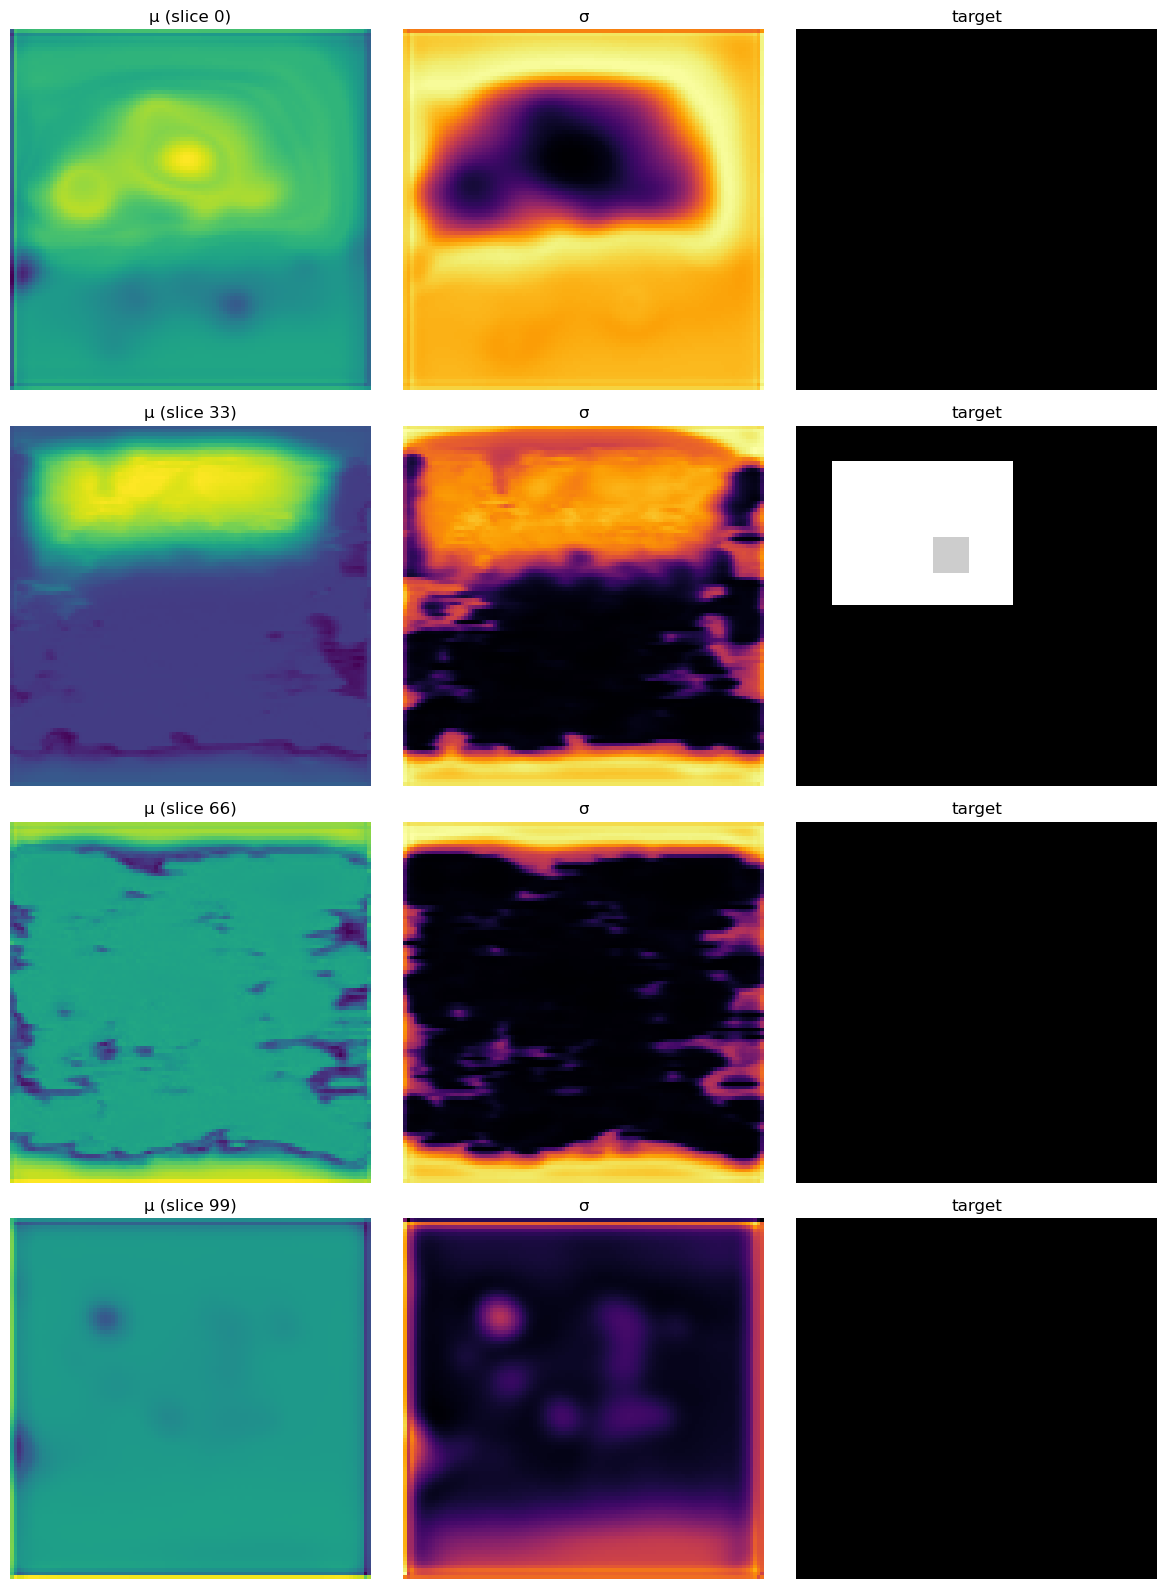

In [61]:
plot_slices(mu, sigma, y, axis="x", n_slices=4, batch_idx=1)